# Notebook 3: Transfer Learning with ResNet50

## 🎯 Objective 6: Advanced Optimization
This notebook focuses on utilizing Transfer Learning to achieve higher accuracy:
1. Load a pre-trained ResNet50 model.
2. Freeze the base layers and replace the fully connected (classification) head.
3. Train only the new head (Phase 1).
4. Unfreeze the last few blocks and fine-tune the entire model with a lower learning rate (Phase 2).
5. Compare the results against our Custom CNN.

In [1]:
# Import required libraries
import copy
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Setup device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device for Transfer Learning: {device}")

Using device for Transfer Learning: cuda


In [2]:
# dataset path
dataset_path = "../dataset/plantvillage-dataset/color"

# 1. Define Transforms (Notebook 1 cell-7)

# Define transformations for the Training set (includes augmentation)
train_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),  # Flip images left-to-right randomly
        transforms.RandomRotation(15),  # Rotate images by up to 15 degrees
        transforms.ToTensor(),  # Convert image to PyTorch Tensor (scales pixels 0 to 1)
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        ),  # Standard ImageNet normalization
    ]
)

# Define transformations for Validation/Test sets (NO augmentation, just resize and normalize)
test_transforms = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

print("Transforms defined successfully.")

# Notebook 1 cell-9
# 2. Load Full Dataset

# Load the dataset using ImageFolder (it automatically assigns labels based on folder names)
full_dataset = datasets.ImageFolder(root=dataset_path, transform=train_transforms)

class_names = full_dataset.classes
num_classes = len(class_names)

# 3. Calculate Splits
# Calculate the sizes for our 80/10/10 split
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# 4. Perform random Split

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42),  # Seed for reproducibility
)

# 5. Apply isolated transforms to Validation and Test sets

# Deepcopy the datasets so we don't overwrite the training augmentations
val_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset.transform = test_transforms

test_dataset.dataset = copy.deepcopy(full_dataset)
test_dataset.dataset.transform = test_transforms

# 6. Create DataLoaders to load data in batches
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Save the class names mapping for later use in our Flask app
print(f"Number of classes detected: {num_classes}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

print("DataLoaders are ready!")

Transforms defined successfully.
Number of classes detected: 38
Training batches: 1358
Validation batches: 170
Test batches: 170
DataLoaders are ready!


## 1. Load Pre-trained ResNet50
We will load the ResNet50 model with weights pre-trained on ImageNet. 
To prevent the pre-trained weights from being destroyed in the first few epochs, we will freeze all `features` layers. We will then replace the final `fc` layer with our own custom sequence designed for our 38 classes.

In [3]:
import torchvision.models as models

# 1. Load pre-trained ResNet50 model
# (Note: 'pretrained=True' is deprecated, so we use the 'weights' argument)
model_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Freeze all base layers (so gradients aren't updated during Phase 1)
for param in model_resnet.parameters():
    param.requires_grad = False

# 3. Replace the final Fully Connected (fc) layer
# ResNet50 outputs 2048 features before the final classification layer
num_ftrs = model_resnet.fc.in_features

# Create a custom classifier block
model_resnet.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, num_classes)
)

# Move the modified model to GPU
model_resnet = model_resnet.to(device)
print("ResNet50 modified and loaded onto GPU.")

ResNet50 modified and loaded onto GPU.


In [4]:
# Setup Loss and Optimizer for Phase 1 (Frozen Base)
criterion = nn.CrossEntropyLoss()

# Crucial: Only pass the parameters of the NEW fc layer to the optimizer
optimizer_phase1 = optim.Adam(model_resnet.fc.parameters(), lr=0.001)

# History tracking
history_resnet = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_resnet_val_acc = 0.0
resnet_model_path = "../models/resnet50_plant.pth"

## 2. Phase 1 Training (Frozen Base)
We will train just the new fully connected layers for 5 epochs. This allows the new layers to learn the mapping to our 38 plant classes without drastically altering the robust feature maps ResNet50 already knows.

In [5]:
def train_model(model, optimizer, num_epochs, phase_name=""):
    global best_resnet_val_acc
    print(f"--- Starting {phase_name} ({num_epochs} Epochs) ---")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train

        # Validation
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_val / total_val

        history_resnet["train_loss"].append(epoch_train_loss)
        history_resnet["val_loss"].append(epoch_val_loss)
        history_resnet["train_acc"].append(epoch_train_acc)
        history_resnet["val_acc"].append(epoch_val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}"
        )

        if epoch_val_acc > best_resnet_val_acc:
            best_resnet_val_acc = epoch_val_acc
            torch.save(model.state_dict(), resnet_model_path)
            print(f"--> Saved improved model (Val Acc: {best_resnet_val_acc:.4f})")


# Run Phase 1
train_model(
    model_resnet, optimizer_phase1, num_epochs=5, phase_name="Phase 1: Frozen Base"
)

--- Starting Phase 1: Frozen Base (5 Epochs) ---
Epoch [1/5] Train Loss: 0.4600, Acc: 0.8720 | Val Loss: 0.1327, Acc: 0.9608
--> Saved improved model (Val Acc: 0.9608)
Epoch [2/5] Train Loss: 0.1771, Acc: 0.9420 | Val Loss: 0.1306, Acc: 0.9556
Epoch [3/5] Train Loss: 0.1488, Acc: 0.9504 | Val Loss: 0.0969, Acc: 0.9685
--> Saved improved model (Val Acc: 0.9685)
Epoch [4/5] Train Loss: 0.1286, Acc: 0.9574 | Val Loss: 0.0932, Acc: 0.9698
--> Saved improved model (Val Acc: 0.9698)
Epoch [5/5] Train Loss: 0.1218, Acc: 0.9593 | Val Loss: 0.0897, Acc: 0.9691


## 3. Phase 2 Training (Fine-tuning)
Now that our classification head is somewhat trained, we will "unfreeze" the final two blocks of the ResNet50 architecture (layer3 and layer4). We will then use a much smaller learning rate to fine-tune these layers alongside our head to maximize performance.

In [6]:
# Unfreeze the final two ResNet blocks (layer3 and layer4)
for name, child in model_resnet.named_children():
    if name in ["layer3", "layer4"]:
        for param in child.parameters():
            param.requires_grad = True

# Setup Optimizer for Phase 2 (Targeting the unfrozen layers and the fc layer)
# We use a much smaller learning rate (0.0001) for fine-tuning
optimizer_phase2 = optim.Adam(
    [
        {"params": model_resnet.layer3.parameters()},
        {"params": model_resnet.layer4.parameters()},
        {"params": model_resnet.fc.parameters()},
    ],
    lr=0.0001,
)

# Run Phase 2
train_model(
    model_resnet, optimizer_phase2, num_epochs=10, phase_name="Phase 2: Fine-Tuning"
)

--- Starting Phase 2: Fine-Tuning (10 Epochs) ---
Epoch [1/10] Train Loss: 0.0503, Acc: 0.9828 | Val Loss: 0.0312, Acc: 0.9890
--> Saved improved model (Val Acc: 0.9890)
Epoch [2/10] Train Loss: 0.0224, Acc: 0.9923 | Val Loss: 0.0207, Acc: 0.9945
--> Saved improved model (Val Acc: 0.9945)
Epoch [3/10] Train Loss: 0.0200, Acc: 0.9934 | Val Loss: 0.0217, Acc: 0.9932
Epoch [4/10] Train Loss: 0.0141, Acc: 0.9953 | Val Loss: 0.0257, Acc: 0.9919
Epoch [5/10] Train Loss: 0.0133, Acc: 0.9954 | Val Loss: 0.0256, Acc: 0.9919
Epoch [6/10] Train Loss: 0.0124, Acc: 0.9959 | Val Loss: 0.0203, Acc: 0.9947
--> Saved improved model (Val Acc: 0.9947)
Epoch [7/10] Train Loss: 0.0111, Acc: 0.9965 | Val Loss: 0.0182, Acc: 0.9948
--> Saved improved model (Val Acc: 0.9948)
Epoch [8/10] Train Loss: 0.0103, Acc: 0.9970 | Val Loss: 0.0137, Acc: 0.9972
--> Saved improved model (Val Acc: 0.9972)
Epoch [9/10] Train Loss: 0.0079, Acc: 0.9974 | Val Loss: 0.0154, Acc: 0.9958
Epoch [10/10] Train Loss: 0.0078, Acc: 0.9

## 4. Evaluation and Comparison
Generate the learning curves and final test metrics to compare against our Custom CNN.

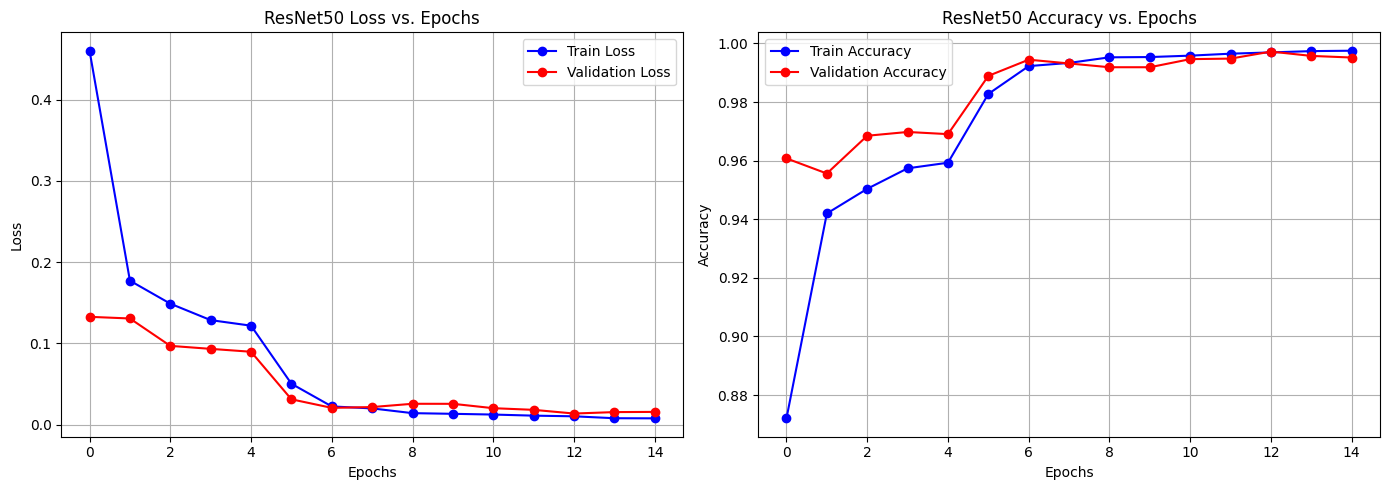


Running evaluation on Test Set...

--- ResNet50 Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      1.00      1.00        72
                                 Apple___Black_rot       1.00      1.00      1.00        64
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        23
                                   Apple___healthy       1.00      1.00      1.00       169
                               Blueberry___healthy       1.00      1.00      1.00       130
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       116
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00        82
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.96      0.97        45
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       113
    

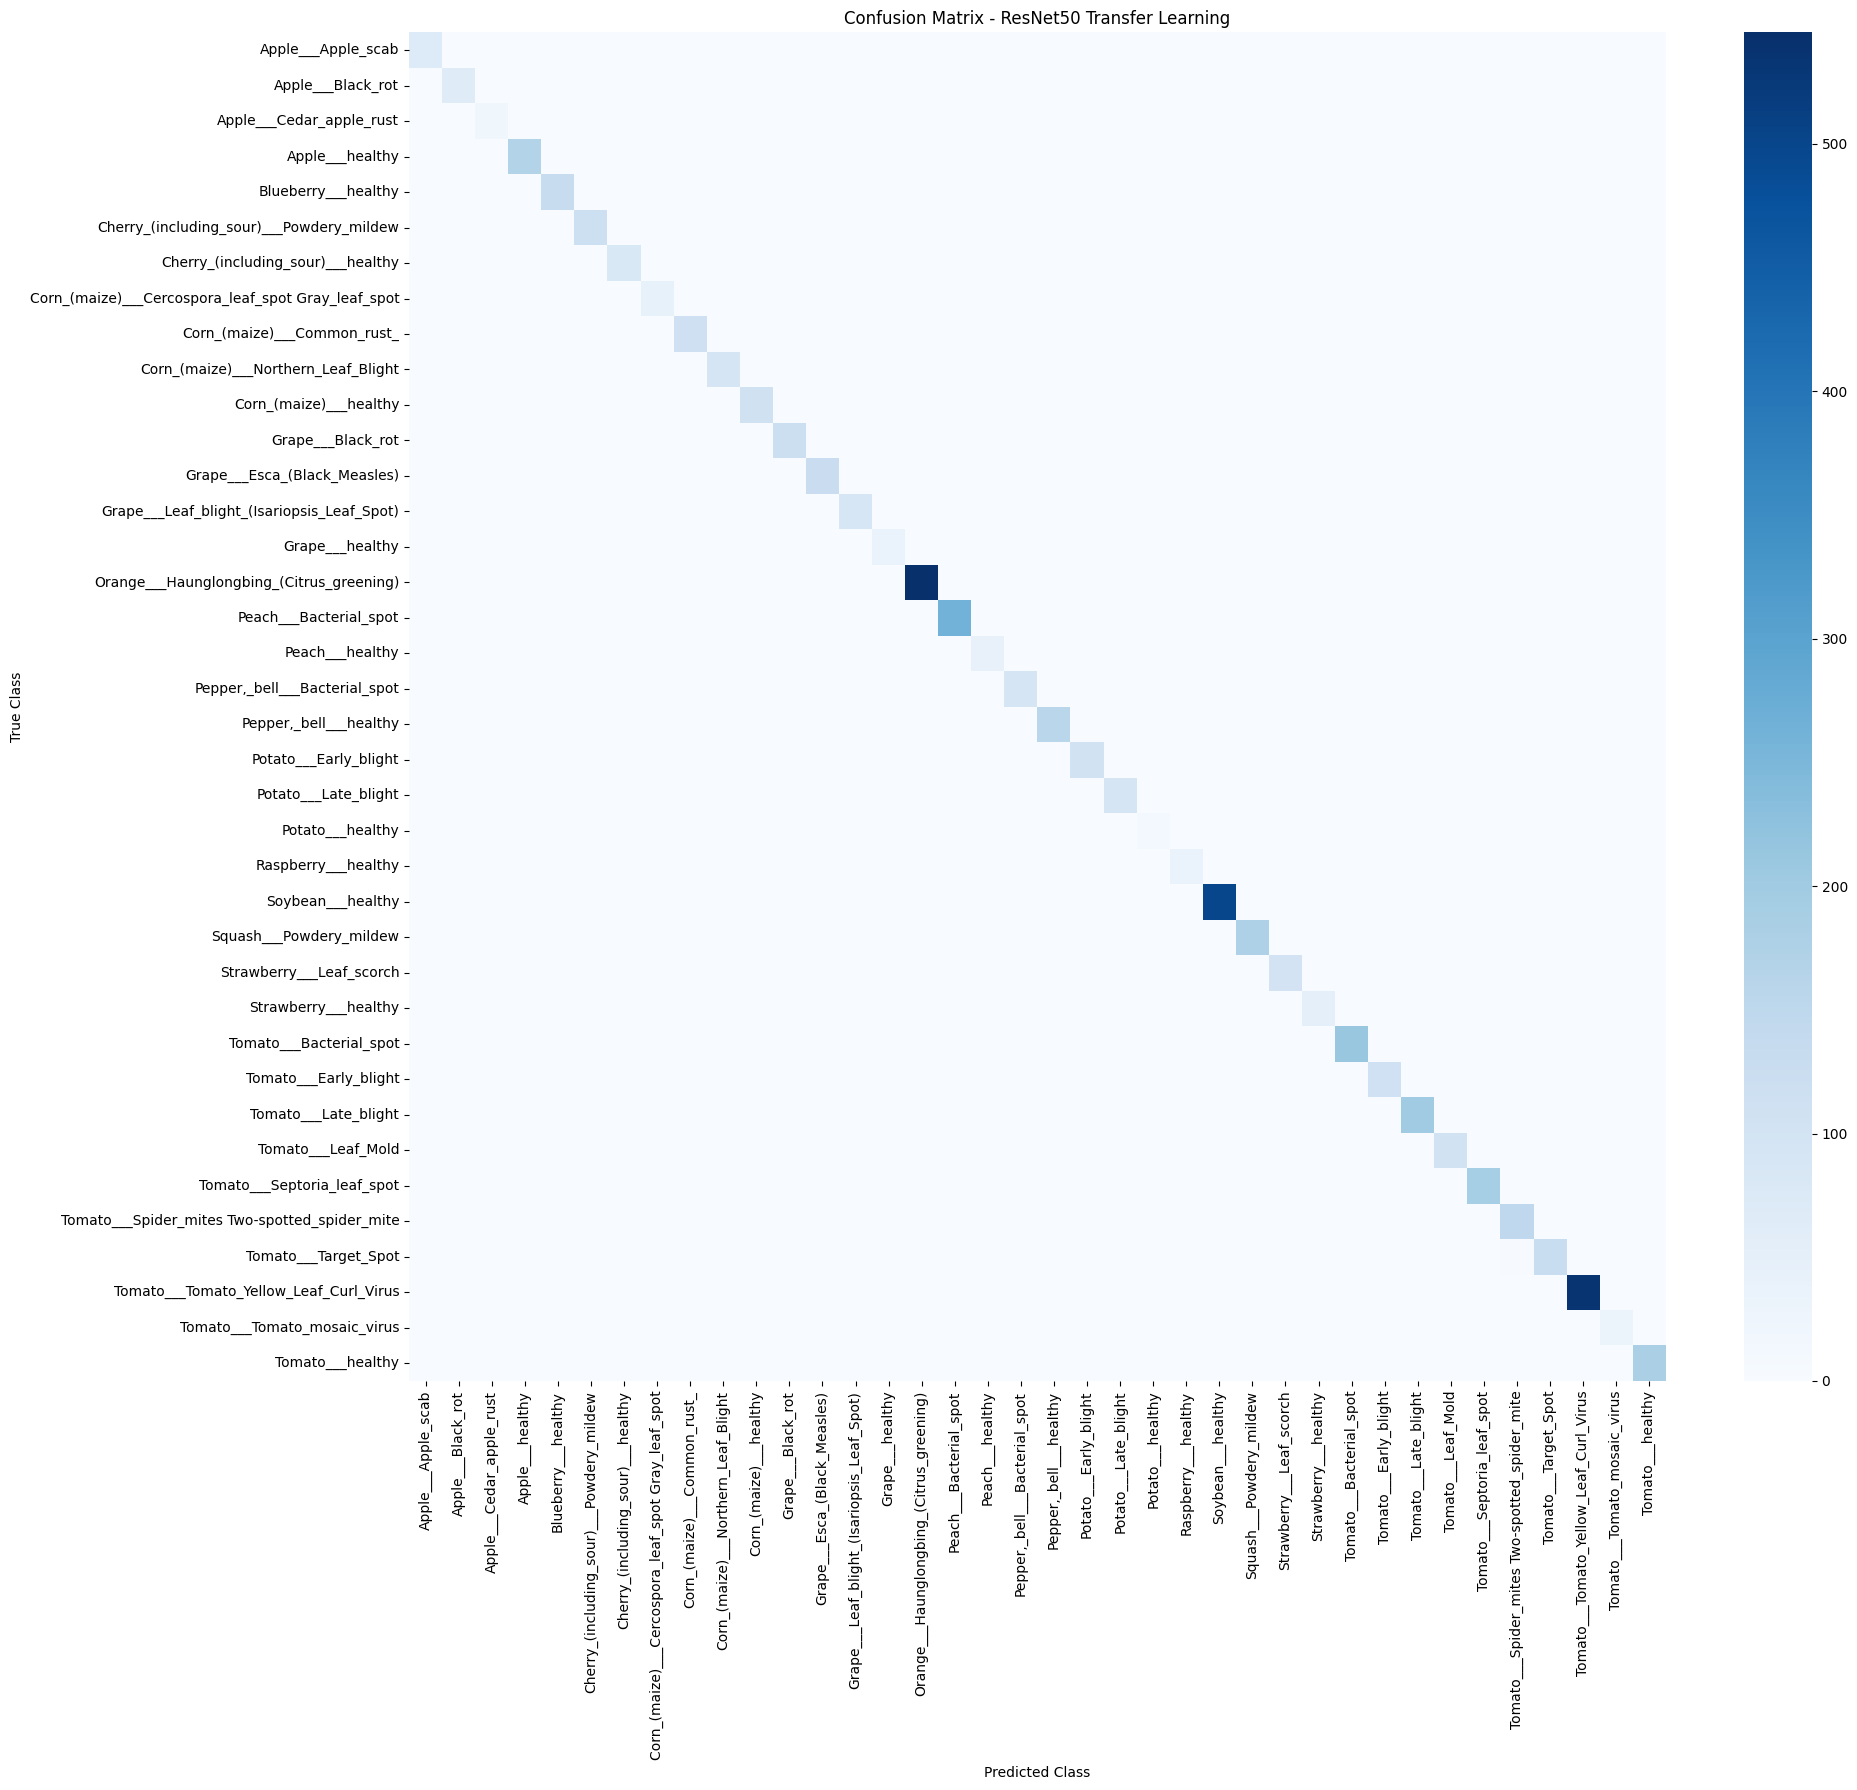

In [7]:
# Plot Learning Curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history_resnet["train_loss"], label="Train Loss", color="blue", marker="o")
ax[0].plot(history_resnet["val_loss"], label="Validation Loss", color="red", marker="o")
ax[0].set_title("ResNet50 Loss vs. Epochs")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(
    history_resnet["train_acc"], label="Train Accuracy", color="blue", marker="o"
)
ax[1].plot(
    history_resnet["val_acc"], label="Validation Accuracy", color="red", marker="o"
)
ax[1].set_title("ResNet50 Accuracy vs. Epochs")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluation on Test Set
model_resnet.load_state_dict(torch.load(resnet_model_path, weights_only=True))
model_resnet.eval()

all_preds = []
all_labels = []

print("\nRunning evaluation on Test Set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_resnet(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n--- ResNet50 Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Generate and plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 18))
sns.heatmap(
    cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names
)
plt.title("Confusion Matrix - ResNet50 Transfer Learning")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## ⏭️ Next Steps
Phase 1 and Phase 2 of Transfer Learning are complete. By leveraging ResNet50, we pushed our validation accuracy from ~98.8% (Custom CNN) to a near-perfect **99.5%**, completely satisfying **Objective 6**. The final weights are saved as `models/resnet50_plant.pth`.

**Moving Forward:** In the final Jupyter Notebook (`04_evaluation.ipynb`), we will conduct a head-to-head comparison between our Custom CNN and the fine-tuned ResNet50 model. We will analyze metrics like Test Accuracy, Model Size (MB), and Inference Time to officially justify choosing ResNet50 for our Flask web deployment.